In [1]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

# Load Data

X, y = make_classification(n_samples=5000, n_features = 5, n_informative=3, weights=[0.9,0.1], n_classes=2, random_state=3)
# plt.scatter(X[:,0], X[:,1], c=y)
print(f'Class Distribution: {np.bincount(y)}')

# Build pipeline (model + preprocessing) - no leakage
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight='balanced',max_iter=1000))
])

# cross - validation: every sample tested exactly once
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    pipeline, X, y, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True  # compare train vs test for overfitting
)
print(f'Cross Validation Results')
print('=' * 60)
for metric in ['accuracy', 'precision', 'recall', 'f1','roc_auc']:
  train = cv_results[f"train_{metric}"]
  test = cv_results[f"test_{metric}"]
  gap = train.mean() - test.mean()
  print(f'{metric:12}: train={train.mean():.3f} test={test.mean():.3f} gap={gap:.3f}')

# Final Test set (touch once for unbaised estimate)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.2, stratify=y, random_state=42
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]

print(f"Final Test Set Results:")
print("=" * 60)
print(classification_report(y_test,y_pred))
print(f"Auc-Roc : {roc_auc_score(y_test,y_proba):.3f}")


Class Distribution: [4481  519]
Cross Validation Results
accuracy    : train=0.853 test=0.852 gap=0.001
precision   : train=0.402 test=0.401 gap=0.001
recall      : train=0.855 test=0.854 gap=0.002
f1          : train=0.547 test=0.546 gap=0.002
roc_auc     : train=0.920 test=0.920 gap=0.000
Final Test Set Results:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      3585
           1       0.41      0.87      0.55       415

    accuracy                           0.85      4000
   macro avg       0.69      0.86      0.73      4000
weighted avg       0.92      0.85      0.88      4000

Auc-Roc : 0.923


Learning Curves: Diagnose Overfitting vs Underfitting

Generate and interpret learning curves to decide if you need more data or a better model




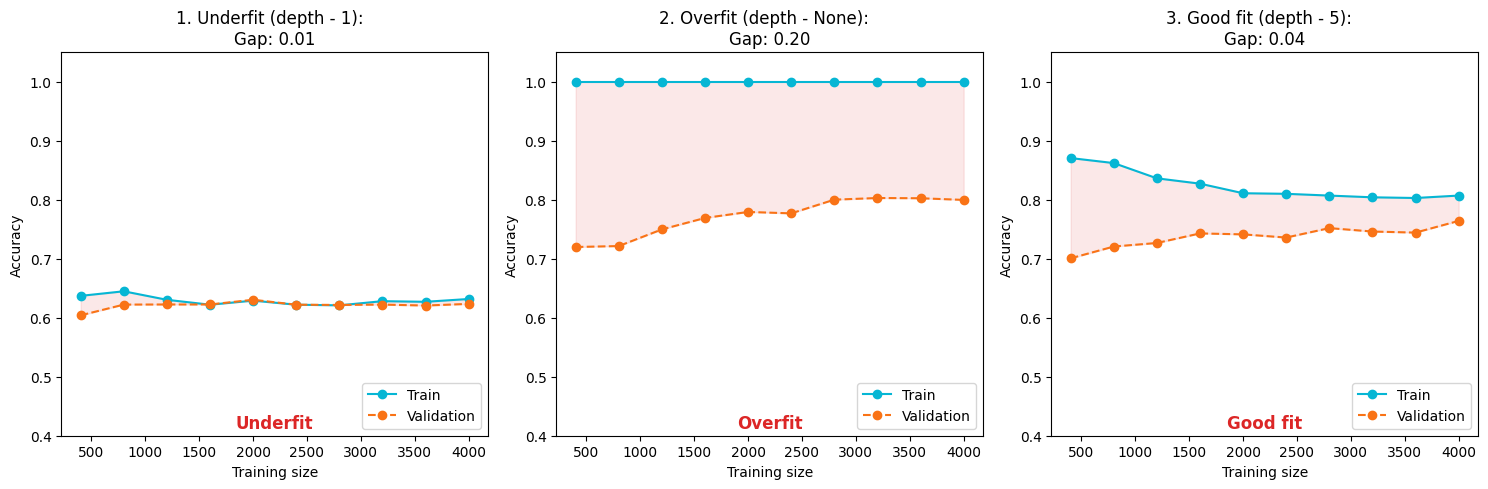


Diagnosis Guide:
  Underfit: Both low, small gap -> Need complex model
  Overfit:  Train high, val low, large gap -> Need more data/regularization
  Good Fit: Both high, small gap -> Ready to deploy!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_classification
from sklearn.model_selection import learning_curve

X,y = make_classification(n_samples = 5000, n_features = 30, n_informative= 20, random_state=42)

# compare underfitting, overfitting and good fit

models = {
    "1. Underfit (depth - 1): ": DecisionTreeClassifier(max_depth=1),
    "2. Overfit (depth - None): ": DecisionTreeClassifier(max_depth=None),
    "3. Good fit (depth - 5): ": DecisionTreeClassifier(max_depth=5),
}

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, (name, model) in zip(axes, models.items()):
  pipeline = Pipeline([
      ('scaler', StandardScaler()),
      ('model', model)
  ])
  train_sizes, train_scores, val_scores = learning_curve(
      pipeline, X, y,
      train_sizes=np.linspace(0.1, 1.0, 10),
      cv=5, scoring='accuracy', n_jobs=1
  )
  train_mean = train_scores.mean(axis=1)
  val_mean = val_scores.mean(axis=1)
  gap = (train_mean[-1] - val_mean[-1])

  ax.plot(train_sizes, train_mean, 'o-', label='Train', color='#06b6d4')
  ax.plot(train_sizes, val_mean, 'o--', label='Validation', color='#f97316')
  ax.fill_between(train_sizes, train_mean, val_mean, alpha=0.1, color='#dc2626')
  ax.set_title(f"{name} \nGap: {gap:.2f}")
  ax.set_xlabel(f"Training size")
  ax.set_ylabel(f"Accuracy")
  ax.set_ylim(0.4, 1.05)
  ax.legend(loc='lower right')

  # Diagnosis
  diagnosis = 'Underfit' if val_mean[-1] < 0.75 and gap < 0.1 else \
              'Overfit' if gap > 0.15 else 'Good fit'

  ax.annotate(diagnosis, xy=(0.5, 0.02), xycoords='axes fraction',
                ha='center', fontsize=12, fontweight='bold',
                color='#dc2626' if diagnosis != 'GOOD FIT' else '#15803d')

plt.tight_layout()
plt.savefig('learning_curves_comparison.png', dpi=150)
plt.show()

print("\nDiagnosis Guide:")
print("  Underfit: Both low, small gap -> Need complex model")
print("  Overfit:  Train high, val low, large gap -> Need more data/regularization")
print("  Good Fit: Both high, small gap -> Ready to deploy!")

Nested Cross-Validation for Hyperparameter Tuning

Unbiased evaluation with inner CV for tuning and outer CV for performance estimation




In [3]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import (GridSearchCV, cross_val_score, StratifiedKFold)
from sklearn.datasets import make_classification

X, y = make_classification(n_samples = 5000, n_features = 5, n_informative = 3, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(probability=True))
])

param_grid = {
    'svc__C': [0.1,1,10],
    'svc__kernel': ['rbf', 'linear'],
    'svc__gamma':['scale','auto']
}

#inner cv - tunes hyperparameter

inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    pipeline, param_grid, cv=inner_cv,
    scoring = 'f1', n_jobs=-1, refit=True
)

#outer cv estimates real performance
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
nested_scores = cross_val_score(
    grid_search, X, y, cv=outer_cv, scoring='f1'
)

print("NESTED CV RESULTS (unbiased)")
print("=" * 50)
print(f"F1 scores per fold: {nested_scores.round(3)}")
print(f"Mean F1: {nested_scores.mean():.3f} (+/- {nested_scores.std()*2:.3f})")


# ============================================================
# COMPARE: Non-nested (biased) estimate
# ============================================================
grid_search.fit(X, y)
print(f"\nNon-nested best CV score: {grid_search.best_score_:.3f}")
print(f"Best params: {grid_search.best_params_}")
print(f"\nNested is typically LOWER than non-nested.")
print(f"The difference shows tuning bias: {grid_search.best_score_ - nested_scores.mean():.3f}")


NESTED CV RESULTS (unbiased)
F1 scores per fold: [0.921 0.933 0.937 0.948 0.927]
Mean F1: 0.933 (+/- 0.019)

Non-nested best CV score: 0.930
Best params: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}

Nested is typically LOWER than non-nested.
The difference shows tuning bias: -0.003
